In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from driver_genes.viutils import valid_filename, get_palette
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42
sns.set_theme(style="ticks")

In [5]:
job_info_df = pd.read_csv('job_info_benchmark.csv')

## collect results from all runs

In [ ]:
unplanned_list = []
failed_list = []
metrics_list = []
# for logit in logit_dict.keys():
for info_dict in job_info_df.to_dict(orient='records'):
    job_dir = os.path.join(
        f'../results/benchmark', 
        info_dict['job_name'], 
        f"{info_dict['split_version']}-seed42"
    )
    metrics_path = os.path.join(job_dir, 'test_epoch_metrics.csv')
    pertgenes_path = os.path.join(job_dir, 'pertgenes.txt')
    if not os.path.exists(pertgenes_path):
        print(f'{pertgenes_path} does not exist')
        unplanned_list.append({
            'job_name': info_dict['job_name'],
            'split_version': info_dict['split_version'],
        })
        continue
    if not os.path.exists(metrics_path):
        print(f'{metrics_path} does not exist')
        failed_list.append({
            'job_name': info_dict['job_name'],
            'split_version': info_dict['split_version'],
        })
        continue
    duration = os.path.getmtime(metrics_path) - os.path.getmtime(pertgenes_path)
    metrics= pd.read_csv(metrics_path, index_col=0).query('Group != "All"').reset_index(drop=True)
    metrics['seed'] = metrics['seed'].astype(str)
    metrics['Dataset'] = info_dict['Dataset']
    metrics['Train on'] = info_dict['Train on']
    metrics['Test on'] = metrics['Group'].map(lambda x: info_dict['Test on'] if x == 'OOD' else info_dict['Train on'] if x == 'ID' else None)
    metrics_list.append(metrics)
metrics_df = pd.concat(metrics_list)
metrics_df['Method'] = 'Ours' 
failed_df = pd.DataFrame(failed_list)
unplanned_df = pd.DataFrame(unplanned_list)

In [ ]:
other_metrics_df = pd.read_parquet('data/benchmark_metrics.parquet')
# filter out the metrics of our model from the previous runnings
other_metrics_df = other_metrics_df.query('Method != "Ours"')

In [ ]:
all_metrics_df = pd.concat([
    metrics_df,
    other_metrics_df
], axis=0, join='inner')

In [ ]:
all_metrics_df.to_parquet('data/benchmark_metrics.parquet')

## plot the results

In [10]:
# all_metrics_df = pd.read_parquet('data/benchmark_metrics.parquet')
all_metrics_df = pd.read_parquet('data/metrics_comparison.parquet')
all_metrics_df.rename(columns=lambda x: x.replace('sample#', ''), inplace=True) # remove the sample# prefix

In [11]:
col_order = [
    'Norman', 'Kowalski', 'Schmidt' , 
    'Nadig', 'Replogle', 'Replogle (strong perturbation)', 
    'Simulation'
]
hue_order = [
    'Ours', 'CellNavi', 
    'GEARS', 'CPA', 'DEG'
]
metric_keys = [
    'RelPos', 'ACC@Top1', 'Recall@Top5',
    'label#AUROC', 'label#AUPRC', 'label#F1'  
]
id_vars = ['Method', 'Test on', 'Dataset']
colors_sel = get_palette().colors
colors_sel

['#A67EB7', '#6F94CD', '#5DA39D', '#EF845D', '#9AA7B1']

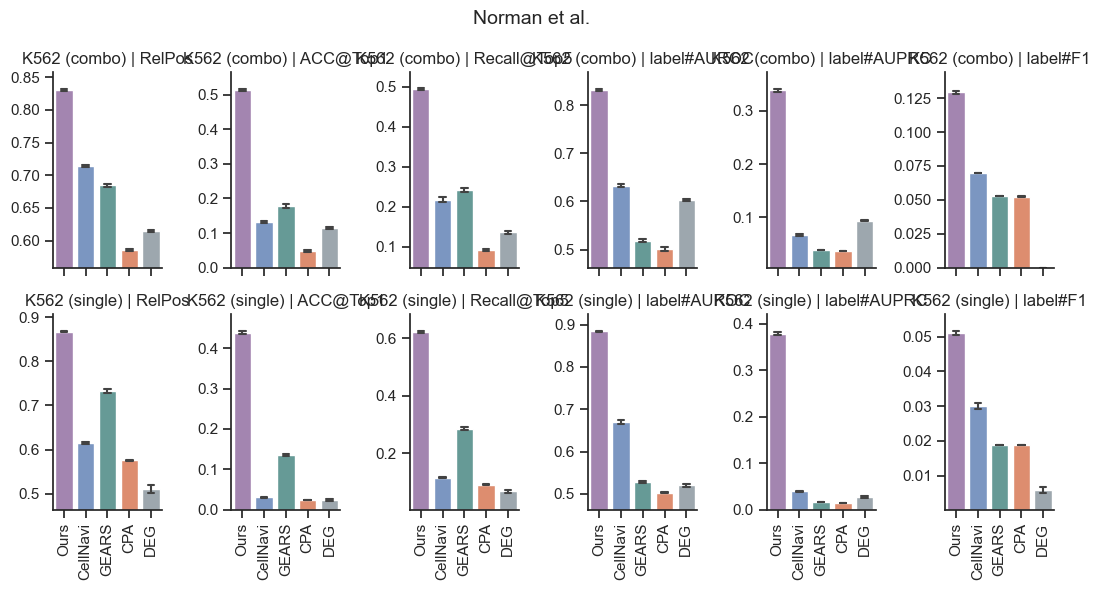

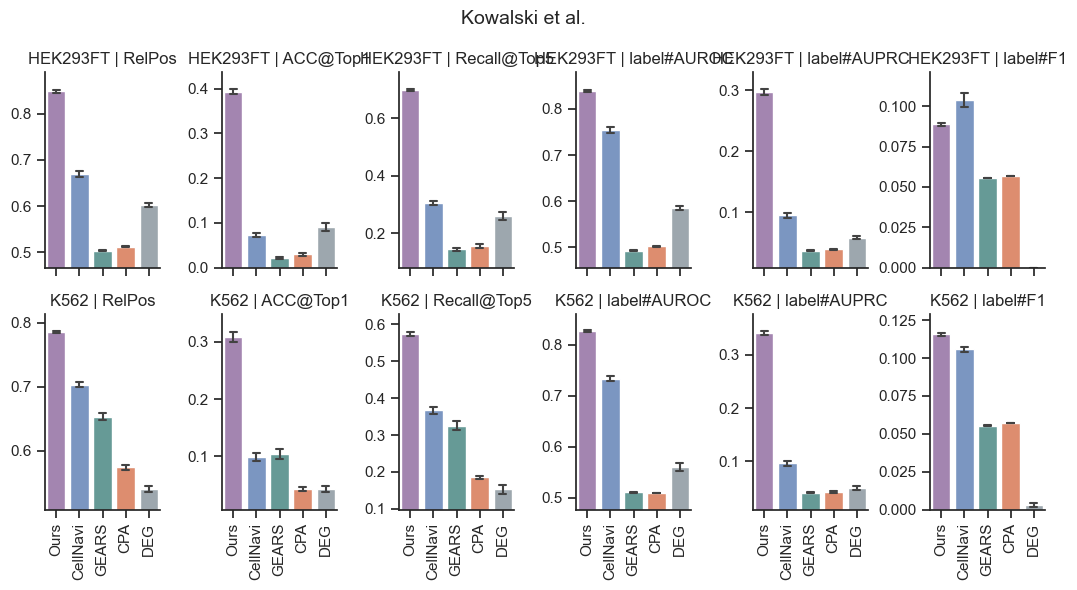

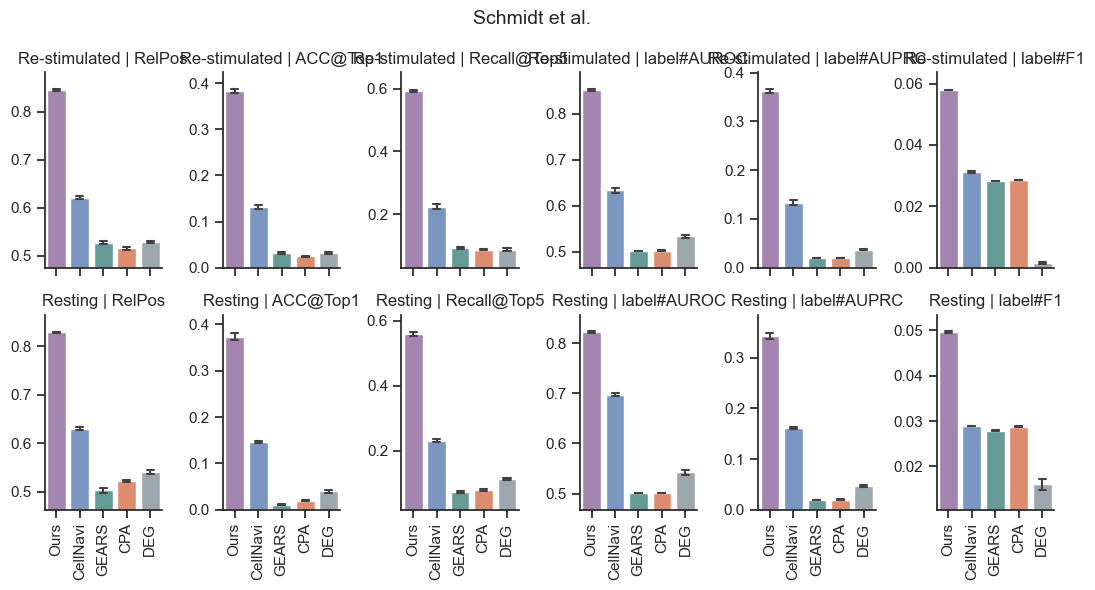

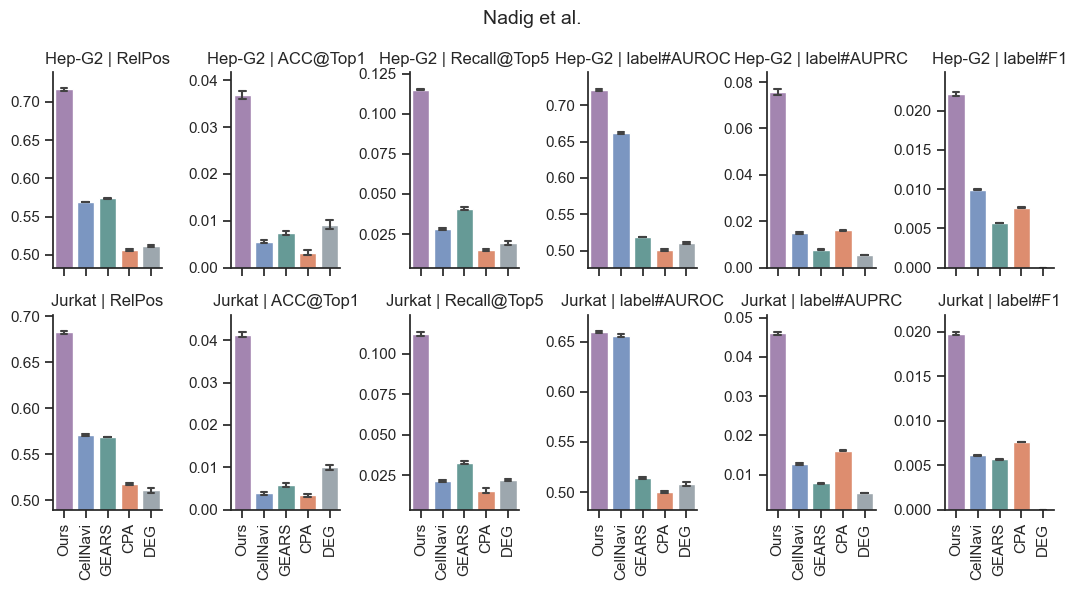

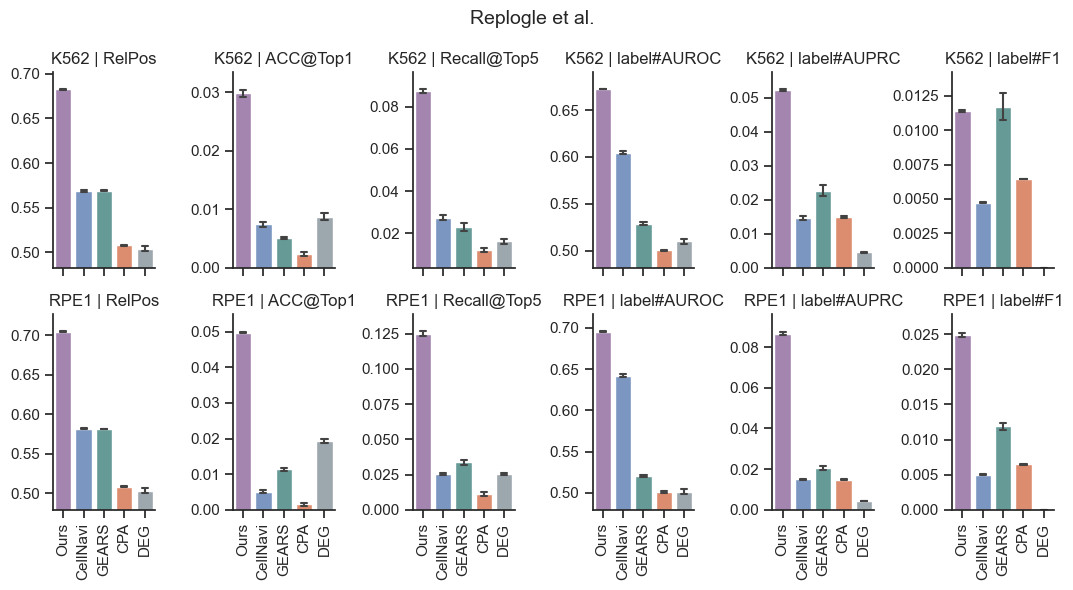

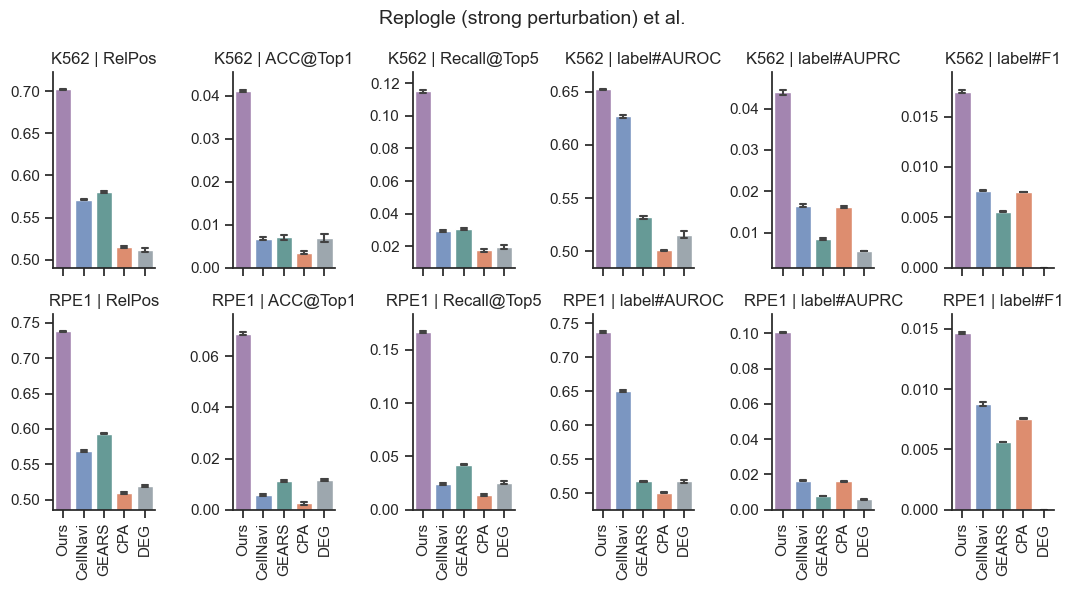

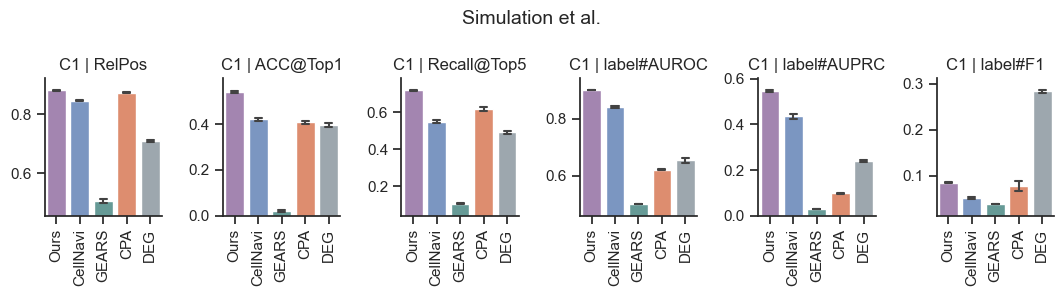

In [14]:
for dataset in col_order:
    plot_df = (
        all_metrics_df
        .query('(Dataset == @dataset) and (Group != "ID" or Dataset == "Norman")')
        .groupby(id_vars)
        [metric_keys + id_vars]
        .sample(n=5)
        # .reset_index(drop=False)
        .melt(id_vars=id_vars, var_name='Metric', value_name='Value')
    )
    g = sns.catplot(
        kind='bar',
        data=plot_df,
        x='Method',
        order=hue_order,
        y='Value',
        row='Test on',
        col='Metric',
        errorbar='sd',
        capsize=0.3,
        err_kws={'linewidth': 1.5},
        hue='Method',
        hue_order=hue_order,
        palette=colors_sel,
        sharey=False,
        height=3,
        aspect=0.6,
    )
    g.set_titles('{row_name} | {col_name}')
    g.set_xlabels("")
    g.set_ylabels("")
    g.tick_params(axis="x", labelrotation=90)
    for j, metric in enumerate(g.col_names):          # col='Metric'
        for i, test_on in enumerate(g.row_names):     # row='Test on'
            ax = g.axes[i, j]

            s = plot_df.loc[
                (plot_df["Metric"] == metric) & (plot_df["Test on"] == test_on),
                "Value"
            ].dropna()

            lo, hi = s.min(), s.max()
            pad = 0.1 * (hi - lo) if hi > lo else (abs(hi) * 0.1 + 1e-6)
            ax.set_ylim(max(0, lo - pad), hi + pad)
    g.figure.suptitle(dataset + ' et al.', fontsize=14)
    g.figure.tight_layout()
    g.figure.savefig(f'../figures/2_benchmarking_metrics_{dataset}.pdf')
    g.figure.show()
        